In [1]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# Generalized Cost on the V2 Areas — Data Inventory, First-Fill Skims and Gaps

`docs/LRT_CAPTURE_PLAN.md` fixes the generalized-cost formula for the capture model, in generalized minutes:

`GC_m = IVT + 2.0 · walk + 2.0 · wait + 8 · transfers + (fare + parking) / VOT`

This notebook asks, component by component and mode by mode (car, bus, LRT), **what is already in the repository or in the new inputs, what can be derived from it now, what has to be assumed, and what is missing** — and fills a first 25 × 25 area matrix for every component with its status recorded cell by cell.

| Component | Car | Bus | LRT |
|---|---|---|---|
| In-vehicle time (IVT) | **derived** — survey door-to-door `TrvlTime` per area pair (2017 / 18 THS, AM car trips), smoothed by a time = a + b · distance fit where cells are thin | **derived** — scheduled in-vehicle time of the direct services in the national GTFS (step 29, `Output/gtfs/bus_direct_skim_area_v2.csv`) where a direct service exists; elsewhere the fastest path on the May 2026 bus-speed street network scaled by the median GTFS ÷ floor ratio (a lower bound: no transfer) | **derived** — station-to-station times of step 25 for the ten trunk areas on `hf_lrt_3`; **missing** for 211, 212 and the branches |
| Walk (access + egress) | assumed — 0 beyond the door-to-door survey time | **derived** — TAZ-centroid to nearest served GTFS stop (step 29), population / employment weighted per area | **derived** — TAZ-centroid to nearest-station distance, population / employment weighted per area |
| Wait | none | **derived** — half the combined headway of the direct services in 07:00–08:00 (GTFS), capped at 10 min; assumed where no direct service | assumed — 5-minute headway, 12 departures an hour |
| Transfers | none | 0 where a direct service exists (GTFS); **missing** elsewhere (path building) | 0 on the trunk; branches n/a |
| Fare, parking, VOT | **missing** — fare tables, parking charges, נוהל פר"ת VOT; the survey's `parkType` gives a paid-parking share by destination area as a proxy | **missing** — fare tables | **missing** — fare policy |

Status codes used throughout: `measured` (observed for the cell), `derived` (computed from data with a stated rule), `assumed` (a stated default, to be replaced), `missing` (no value; a placeholder is written so the matrix is complete, flagged).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shapefile
from shapely.geometry import shape
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import dijkstra, connected_components
from scipy.spatial import cKDTree

BLUE, ORANGE, AQUA, PURPLE, INK, INK2, MUTED, GRID, AXIS = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
OUT = 'Output/gc'; os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
# ---- generalized-cost parameters of docs/LRT_CAPTURE_PLAN.md (defaults, flagged as assumed) ----
W_WALK, W_WAIT, TRANSFER_PEN = 2.0, 2.0, 8.0
HEADWAY = {'bus': 10.0, 'lrt': 5.0}                 # min; LRT: 12 departures an hour (assumption agreed 22 Sep 2026); bus: placeholder for pairs without a GTFS direct service
WAIT_CAP = 10.0
WALK_SPEED = 80.0                                    # m/min (4.8 km/h)
DETOUR = 1.3                                         # straight-line to walking-network factor
BUS_WALK_DEFAULT = 8.0                               # min access + egress, placeholder until GTFS stops are used
VOT = 30.0                                           # ILS per hour — placeholder; to be taken from נוהל פר"ת
FARE = {'bus': 0.0, 'lrt': 0.0}; PARKING = 0.0       # ILS — missing; zero placeholders
# ---- V2 areas, TAZ membership, centroids ----
xl = pd.ExcelFile('Input/Corridor_TAZ_Agg_V2.xlsx'); areas = xl.parse('AreaCodes').set_index('AggCode'); key = xl.parse('TazAgg')
AREAS = list(areas.index); names = areas['AggAreaName']; A = len(AREAS); apos = {a: i for i, a in enumerate(AREAS)}
ac = pd.read_csv('Output/lrt_v2/lrt_area_representative_station.csv', index_col=0).reindex(AREAS)
DIST_KM = pd.DataFrame(np.hypot(ac['cx'].values[:, None] - ac['cx'].values[None, :], ac['cy'].values[:, None] - ac['cy'].values[None, :]) / 1000, index=AREAS, columns=AREAS)
zon = pd.read_csv('Input/Zonal_2020.csv', encoding='windows-1255').set_index('TAZ_ID')
tz = shapefile.Reader('Input/TAZ_North/TAZ_North'); cent = {int(r['TAZ_NUMBER']): shape(s.__geo_interface__).centroid for s, r in zip(tz.shapes(), tz.records())}
print(f"{A} areas; centroid distances 0.9–{DIST_KM.values.max():.1f} km")

25 areas; centroid distances 0.9–35.0 km


## 1. Car in-vehicle time — survey door-to-door times per area pair

In [3]:
# ---- AM car trips of the trips file with their door-to-door time and distance (same extraction as steps 15 / 20) ----
df = pd.read_excel('Input/trips_ths_2017.xlsx')
d = df.sort_values(['PerID3', 'SurveyDay', 'placeno']).copy(); g = d.groupby(['PerID3', 'SurveyDay'])
d['origin'] = g['actTaz'].shift(1); d['trip_dep_h'] = g['Dep_h'].shift(1)
trips = d.dropna(subset=['origin', 'actTaz', 'trip_dep_h']); trips = trips[trips['trip_dep_h'].isin([6, 7, 8])].copy()
COMP = {'CAR': [10, 11], 'BUS': [3, 4], 'TAXI': [5, 8], 'RAIL': [7]}
trips['comp'] = trips['mainmode'].map(lambda m: next((k for k, v in COMP.items() if m in v), 'OTHER'))
# survey zones (2636) -> 1250 zones -> study TAZs by population (origin) / employment (destination) shares, as in step 20
k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636'); map_2636_1250 = k26.set_index('TAZ_2636')['TAZ_1250']
trips['o1250'] = trips['origin'].map(map_2636_1250); trips['d1250'] = trips['actTaz'].map(map_2636_1250)
KEYS_LFS = 'Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv'
keys_raw = pd.read_csv('Input/taz_keys_from_shapefile.csv') if open(KEYS_LFS, 'rb').read(40).startswith(b'version https://git-lfs') else pd.read_csv(KEYS_LFS, encoding='windows-1255')
kd = keys_raw[['TAZ_1270', 'TAZ_NUMBER', 'SZ_NEW']].dropna(subset=['TAZ_NUMBER']).astype({'TAZ_NUMBER': int, 'SZ_NEW': int}).drop_duplicates('TAZ_NUMBER')
children = kd.groupby('TAZ_1270')['TAZ_NUMBER'].apply(list)
area_of = key.set_index('TAZ')['AggCode']
pop = zon['POPULATION'].fillna(0); emp = zon['EMPL_TOT'].fillna(0)
def zone_area_shares(primary, secondary):
    """1250-zone -> V2 area shares (rows sum to <= 1; TAZs outside the 25 areas drop out)."""
    S = {}
    for z, kids in children.items():
        for v in (primary.reindex(kids).fillna(0), secondary.reindex(kids).fillna(0), pd.Series(1.0, index=kids)):
            if v.sum() > 0:
                w = v / v.sum(); s = w.groupby(w.index.map(area_of)).sum(); s = s[s.index.notna()]
                if len(s): S[z] = s.to_dict()
                break
    return S
S_o, S_d = zone_area_shares(pop, emp), zone_area_shares(emp, pop)
def allocate(sub):
    """Long table: trip row, origin area, destination area, share (product of the two allocation shares)."""
    rows = []
    for r in sub.itertuples():
        so, sd = S_o.get(r.o1250), S_d.get(r.d1250)
        if not so or not sd: continue
        for oa, wo in so.items():
            for da, wd in sd.items(): rows.append((r.Index, int(oa), int(da), wo * wd))
    return pd.DataFrame(rows, columns=['row', 'o', 'd', 'share'])
car = trips[trips['comp'] == 'CAR'].copy(); lp = allocate(car)
lp['w'] = lp['share'] * car.loc[lp['row'], 'new_wf'].values; lp['t'] = car.loc[lp['row'], 'TrvlTime'].values; lp['km'] = car.loc[lp['row'], 'TrvlDist'].values
ok = (lp['t'] > 0) & (lp['t'] <= 180) & (lp['km'] > 0) & (lp['w'] > 0)          # drop zero and implausible (> 3 h) door-to-door times and zero-weight records
lp = lp[ok]
agg = lp.groupby(['o', 'd']).apply(lambda x: pd.Series({'t_obs': np.average(x['t'], weights=x['w']), 'km_obs': np.average(x['km'], weights=x['w']), 'n': x['share'].sum()}), include_groups=False).reset_index()
car_t = agg.pivot(index='o', columns='d', values='t_obs').reindex(index=AREAS, columns=AREAS)
car_n = agg.pivot(index='o', columns='d', values='n').reindex(index=AREAS, columns=AREAS).fillna(0)
car_km = agg.pivot(index='o', columns='d', values='km_obs').reindex(index=AREAS, columns=AREAS)
# smoothing: weighted fit t = a + b * centroid distance on the off-diagonal cells, then an EB blend t = (n t_obs + K t_fit) / (n + K)
K_SMOOTH = 5.0
off = agg[agg['o'] != agg['d']].copy(); off['dist'] = [DIST_KM.loc[o, d_] for o, d_ in zip(off['o'], off['d'])]
Wt = np.sqrt(off['n'].values); Xm = np.c_[np.ones(len(off)), off['dist'].values]
a_fit, b_fit = np.linalg.lstsq(Xm * Wt[:, None], off['t_obs'].values * Wt, rcond=None)[0]
diag_t = np.average(agg.loc[agg['o'] == agg['d'], 't_obs'], weights=agg.loc[agg['o'] == agg['d'], 'n'])
tf = a_fit + b_fit * DIST_KM.values; np.fill_diagonal(tf, diag_t); t_fit = pd.DataFrame(tf, index=AREAS, columns=AREAS)
car_ivt = (car_n * car_t.fillna(0) + K_SMOOTH * t_fit) / (car_n + K_SMOOTH)
car_status = pd.DataFrame(np.where(car_n >= 10, 'measured', np.where(car_n > 0, 'derived', 'derived')), index=AREAS, columns=AREAS)   # >= 10 sampled: observed mean; else EB blend with the distance fit
car_ivt.to_csv(f'{OUT}/car_ivt_survey_area_v2.csv', float_format='%.2f'); car_n.to_csv(f'{OUT}/car_ivt_n_sampled_area_v2.csv', float_format='%.2f'); car_km.to_csv(f'{OUT}/car_dist_survey_area_v2.csv', float_format='%.2f')
print(f"AM car trips with a door-to-door time: {ok.sum():,} allocations from {car.loc[lp['row'].unique()].shape[0]:,} sampled trips; area pairs with any sample {int((car_n > 0).sum().sum())} of {A * A}, with ≥ 10 sampled {int((car_n >= 10).sum().sum())}")
print(f"distance fit on off-diagonal cells: t = {a_fit:.1f} + {b_fit:.2f} × km  (survey-implied {60 / b_fit:.1f} km/h marginal speed, {a_fit:.1f} min terminal time); intra-area {diag_t:.1f} min")
car_ivt.round(1)

AM car trips with a door-to-door time: 3,453 allocations from 2,387 sampled trips; area pairs with any sample 296 of 625, with ≥ 10 sampled 35
distance fit on off-diagonal cells: t = 7.0 + 1.85 × km  (survey-implied 32.4 km/h marginal speed, 7.0 min terminal time); intra-area 7.0 min


d,201,202,203,204,205,206,207,208,209,210,...,216,217,101,102,103,104,301,302,303,304
o,,,,,,,,,,,,,,,,,,,,,
201,4.4,12.3,17.1,19.4,27.9,21.7,20.0,21.0,24.5,21.9,...,54.2,67.2,36.3,34.9,32.2,29.5,34.4,32.4,30.3,28.1
202,11.1,8.1,11.5,13.5,22.7,16.5,15.3,17.0,16.5,20.1,...,55.5,69.6,33.8,32.7,30.3,28.0,31.6,29.8,27.8,26.2
203,17.6,11.5,6.0,8.5,10.5,12.9,12.8,14.1,16.4,20.5,...,56.3,71.1,32.3,31.5,29.3,27.5,29.9,28.2,26.4,25.4
204,18.8,12.8,7.8,7.2,6.6,9.9,12.2,14.5,17.5,21.6,...,56.6,71.8,31.4,30.8,28.8,27.2,28.9,27.4,25.7,25.0
205,20.6,14.3,9.7,7.4,5.9,10.3,17.0,12.2,16.7,22.1,...,56.5,71.9,30.4,30.0,28.1,26.8,28.0,26.5,24.9,24.7
206,22.2,17.7,13.6,8.4,10.2,6.0,7.9,10.6,14.8,20.5,...,53.4,62.2,27.3,26.8,24.9,23.3,24.9,23.4,21.8,21.4
207,20.0,15.4,12.8,12.2,11.9,10.1,4.0,8.6,12.3,15.9,...,51.6,67.0,26.5,25.7,23.7,22.1,24.1,22.4,20.7,19.9
208,19.9,16.1,14.1,13.8,13.8,12.1,7.1,6.5,9.6,18.0,...,49.9,60.9,25.2,24.4,22.2,18.6,22.9,21.2,19.3,18.3
209,30.7,16.6,16.4,16.8,17.1,14.5,12.4,10.2,7.7,11.7,...,47.0,62.0,24.6,23.3,20.8,18.4,22.5,20.6,18.5,16.5


## 2. Bus in-vehicle time — fastest bus-served path on the May 2026 speed network

In [4]:
# ---- street network with bus speeds: link speeds for weekday 3, 07:00–08:00, with (AB) and against (BA) the link topology ----
sp = pd.read_csv('Input/BusSpeedData/std_202605.csv', usecols=['USERID', 'd_3_h_7_AB', 'd_3_h_7_BA']).set_index('USERID')
rd = shapefile.Reader('Input/BusSpeedData/Streets/Streets'); BB = tz.bbox
edges = []
for s, rec in zip(rd.iterShapes(), rd.iterRecords()):
    b = s.bbox
    if not (b[2] > BB[0] and b[0] < BB[2] and b[3] > BB[1] and b[1] < BB[3]): continue
    p = s.points; ln = sum(np.hypot(p[i + 1][0] - p[i][0], p[i + 1][1] - p[i][1]) for i in range(len(p) - 1))
    edges.append((p[0][0], p[0][1], p[-1][0], p[-1][1], ln, rec['DIR'], rec['USERID']))
e = pd.DataFrame(edges, columns=['ax', 'ay', 'bx', 'by', 'len', 'dir', 'uid'])
e['vAB'] = e['uid'].map(sp['d_3_h_7_AB']).fillna(0); e['vBA'] = e['uid'].map(sp['d_3_h_7_BA']).fillna(0)
nodes = {}
def node(x, y):
    k = (round(x), round(y))
    if k not in nodes: nodes[k] = len(nodes)
    return nodes[k]
e['a'] = [node(x, y) for x, y in zip(e['ax'], e['ay'])]; e['b'] = [node(x, y) for x, y in zip(e['bx'], e['by'])]
# DIR: 1 = one-way with the topology (AB), -1 = against it (BA), 0 = two-way (99.9 % of the speed records agree with this reading)
rows, cols, tmin, lens = [], [], [], []
for a, b, ln, dr, vab, vba in zip(e['a'], e['b'], e['len'], e['dir'], e['vAB'], e['vBA']):
    if vab > 0 and dr in (0, 1): rows.append(a); cols.append(b); tmin.append(ln / 1000 / vab * 60); lens.append(ln)
    if vba > 0 and dr in (0, -1): rows.append(b); cols.append(a); tmin.append(ln / 1000 / vba * 60); lens.append(ln)
N = len(nodes); G = coo_matrix((tmin, (rows, cols)), shape=(N, N)).tocsr(); GL = coo_matrix((lens, (rows, cols)), shape=(N, N)).tocsr()
ncomp, lab = connected_components(G, directed=True, connection='strong'); giant = np.bincount(lab).argmax()
served = np.array([v for v in set(rows) | set(cols) if lab[v] == giant]); xy = np.array([k for k, v in sorted(nodes.items(), key=lambda kv: kv[1])])
kdt = cKDTree(xy[served]); conn_d, conn_i = kdt.query(ac[['cx', 'cy']].values); anchor = served[conn_i]
print(f"{len(e):,} street links in the study bbox ({e['len'].sum() / 1000:,.0f} km), {((e['vAB'] > 0) | (e['vBA'] > 0)).sum():,} with a bus speed record ({e.loc[(e['vAB'] > 0) | (e['vBA'] > 0), 'len'].sum() / 1000:,.0f} km); "
      f"{N:,} nodes, giant strongly-connected bus component {len(served):,} nodes; area connectors {conn_d.min():.0f}–{conn_d.max():.0f} m")
Dt, pred = dijkstra(G, indices=anchor, directed=True, return_predecessors=True)
bus_arr = Dt[:, anchor].copy()
def path_len(i, j):
    if i == j: return 0.0
    k, tot = anchor[j], 0.0
    while k != anchor[i]:
        p = pred[i, k]
        if p < 0: return np.nan
        tot += GL[p, k]; k = p
    return tot / 1000
bus_km = pd.DataFrame([[path_len(i, j) for j in range(A)] for i in range(A)], index=AREAS, columns=AREAS)
bus_arr = bus_arr + (conn_d[:, None] + conn_d[None, :]) / 1000 / 15 * 60 * (1 - np.eye(A))     # connector legs at 15 km/h (a slow bus on local streets)
assert np.isfinite(bus_arr).all(), 'every area pair must be reachable on the bus-served network'
np.fill_diagonal(bus_arr, np.nan); bus_ivt = pd.DataFrame(bus_arr, index=AREAS, columns=AREAS)
bus_ivt.to_csv(f'{OUT}/bus_ivt_network_area_v2.csv', float_format='%.2f'); bus_km.to_csv(f'{OUT}/bus_path_km_area_v2.csv', float_format='%.2f')
spd = (bus_km / bus_ivt * 60)
print(f"bus fastest-path IVT between area centroids: {np.nanmin(bus_ivt.values):.0f}–{np.nanmax(bus_ivt.values):.0f} min, implied path speed {np.nanmin(spd.values):.0f}–{np.nanmax(spd.values):.0f} km/h (median {np.nanmedian(spd.values):.0f})")
bus_ivt.round(1)

54,507 street links in the study bbox (5,632 km), 48,092 with a bus speed record (4,995 km); 48,898 nodes, giant strongly-connected bus component 37,694 nodes; area connectors 28–625 m


bus fastest-path IVT between area centroids: 3–69 min, implied path speed 18–63 km/h (median 34)


,201,202,203,204,205,206,207,208,209,210,...,216,217,101,102,103,104,301,302,303,304
201,NaN,11.7,17.6,16.9,16.8,19.3,22.4,26.3,34.6,37.9,...,51.9,67.6,45.4,42.7,41.9,37.7,46.9,48.6,45.0,39.0
202,8.5,NaN,10.2,9.5,9.3,11.8,14.9,18.8,27.1,30.4,...,44.5,60.1,38.0,35.3,34.5,30.2,39.5,41.2,37.6,31.6
203,15.4,7.8,NaN,5.3,6.9,9.4,12.5,16.4,26.0,33.1,...,47.1,62.8,40.5,37.8,37.1,32.8,42.0,43.7,40.1,34.1
204,20.1,12.5,5.9,NaN,3.3,5.8,8.9,12.8,22.4,29.5,...,43.5,59.2,36.9,34.2,33.5,29.2,38.4,40.1,36.5,30.5
205,18.6,11.1,8.3,4.5,NaN,3.5,6.6,10.5,20.1,27.2,...,41.3,56.9,34.7,32.0,31.2,27.0,36.2,37.9,34.3,28.3
206,18.8,11.2,10.4,6.6,4.0,NaN,3.6,7.5,17.1,24.2,...,38.3,53.9,31.6,29.0,28.2,23.9,33.1,34.9,31.2,25.3
207,20.7,13.1,12.3,8.5,5.9,6.1,NaN,6.3,15.5,22.6,...,36.7,52.3,30.1,27.4,26.6,22.4,31.6,33.3,29.7,23.7
208,22.0,14.5,13.6,9.8,7.2,9.5,3.9,NaN,13.4,20.5,...,34.5,50.2,27.9,25.2,24.5,20.2,29.4,31.1,27.5,21.5
209,25.5,17.9,22.5,19.2,16.6,17.6,11.9,9.8,NaN,17.7,...,31.8,47.4,25.3,22.6,21.8,17.5,26.8,28.5,24.9,18.9
210,22.0,14.4,18.9,19.4,16.8,17.8,12.1,10.0,12.1,NaN,...,26.0,41.6,18.0,15.3,14.5,10.3,19.5,21.2,17.6,11.6


### 2b. Cross-check — the survey's bus door-to-door times on the same pairs

In [5]:
bus_s = trips[trips['comp'] == 'BUS'].copy(); lb = allocate(bus_s)
lb['w'] = lb['share'] * bus_s.loc[lb['row'], 'new_wf'].values; lb['t'] = bus_s.loc[lb['row'], 'TrvlTime'].values
lb = lb[(lb['t'] > 0) & (lb['t'] <= 180) & (lb['w'] > 0) & (lb['o'] != lb['d'])]
lb['net'] = [bus_ivt.loc[o, d_] for o, d_ in zip(lb['o'], lb['d'])]; lb['trunk'] = lb['o'].between(201, 210) & lb['d'].between(201, 210)
xc = []
for lab, m in [('trunk pairs (201–210)', lb['trunk']), ('all V2 pairs', lb['o'] == lb['o'])]:
    x = lb[m]; xc.append({'pairs': lab, 'sampled bus trips': x['share'].sum(), 'survey door-to-door (min)': np.average(x['t'], weights=x['w']), 'network fastest-path IVT (min)': np.average(x['net'], weights=x['w'])})
xc = pd.DataFrame(xc); xc['ratio'] = xc['survey door-to-door (min)'] / xc['network fastest-path IVT (min)']
xc.to_csv(f'{OUT}/bus_survey_vs_network_check.csv', index=False, float_format='%.2f')
print("survey bus door-to-door against the fastest bus-served path: the ratio is the walk + wait + stops + detour that the network IVT does not carry")
xc.round(2)

survey bus door-to-door against the fastest bus-served path: the ratio is the walk + wait + stops + detour that the network IVT does not carry


,pairs,sampled bus trips,survey door-to-door (min),network fastest-path IVT (min),ratio
0,trunk pairs (201–210),36.92,27.11,11.99,2.26
1,all V2 pairs,102.25,32.38,15.29,2.12


## 2c. The GTFS direct-service skim (step 29): scheduled in-vehicle time, timetable wait, stop access

Where `Output/gtfs/bus_direct_skim_area_v2.csv` exists (step 29 run on the real feed), the bus components are taken from the timetable: in-vehicle time = median scheduled time of the direct services between the two areas in the morning peak; wait = half the combined 07:00–08:00 headway of those services, capped at 10 min; transfers = 0. Pairs without a direct service keep the fastest-path floor scaled by the median GTFS-to-floor ratio, the placeholder wait, and a missing transfer count. Walk access and egress come from the per-TAZ distance to the nearest served stop (`bus_los_taz.csv`), population-weighted for access and employment-weighted for egress. The Metronit BRT is carried as its own mode (`brt`) on the pairs it connects directly.

In [6]:
GTFS_SKIM, GTFS_LOS = 'Output/gtfs/bus_direct_skim_area_v2.csv', 'Output/gtfs/bus_los_taz.csv'
HAVE_GTFS = os.path.exists(GTFS_SKIM) and os.path.exists(GTFS_LOS)
if HAVE_GTFS:
    gs = pd.read_csv(GTFS_SKIM); gl = pd.read_csv(GTFS_LOS).set_index('TAZ')
    ratio = (gs['bus_ivt_min'] / gs['step26_fastest_path_min']).replace([np.inf, -np.inf], np.nan).median() if 'step26_fastest_path_min' in gs else 1.0
    bus_ivt_gtfs = gs.pivot(index='o', columns='d', values='bus_ivt_min').reindex(index=AREAS, columns=AREAS)
    bus_hw_gtfs = gs.pivot(index='o', columns='d', values='bus_headway_0708_min').reindex(index=AREAS, columns=AREAS)
    brt_ivt_gtfs = gs.pivot(index='o', columns='d', values='brt_ivt_min').reindex(index=AREAS, columns=AREAS)
    brt_hw_gtfs = gs.pivot(index='o', columns='d', values='brt_headway_0708_min').reindex(index=AREAS, columns=AREAS)
    direct = bus_ivt_gtfs.notna()
    OBS_SKIM = 'Output/gtfs/bus_observed_skim_area_v2.csv'; HAVE_OBS = os.path.exists(OBS_SKIM)
    if HAVE_OBS:                                              # step 30: the same direct trips routed over the measured bus link speeds
        ob = pd.read_csv(OBS_SKIM)
        bus_ivt_obs = ob.pivot(index='o', columns='d', values='bus_ivt_observed_min').reindex(index=AREAS, columns=AREAS)
        brt_ivt_obs = ob.pivot(index='o', columns='d', values='brt_ivt_observed_min').reindex(index=AREAS, columns=AREAS)
        obs_ratio = float(np.nanmedian((bus_ivt_obs / bus_ivt_gtfs).values))
        bus_ivt_sched = bus_ivt_gtfs.copy(); bus_ivt_gtfs = bus_ivt_obs.where(bus_ivt_obs.notna(), bus_ivt_gtfs)
        brt_ivt_sched = brt_ivt_gtfs.copy(); brt_ivt_gtfs = brt_ivt_obs.where(brt_ivt_obs.notna(), brt_ivt_gtfs)
        print(f"step 30 observed skim: observed ÷ scheduled in-vehicle time, median over the direct pairs {obs_ratio:.2f}; observed values on {int(bus_ivt_obs.notna().values.sum())} pairs replace the scheduled ones")
    bus_ivt_final = bus_ivt_gtfs.where(direct, bus_ivt * ratio)
    bus_wait_final = (bus_hw_gtfs / 2).clip(upper=WAIT_CAP).where(direct, min(HEADWAY['bus'] / 2, WAIT_CAP))
    bus_ivt_status = pd.DataFrame(np.where(direct, 'derived', 'assumed'), index=AREAS, columns=AREAS); bus_ivt_status.values[np.eye(A, dtype=bool)] = 'missing'
    bus_wait_status = pd.DataFrame(np.where(direct, 'derived', 'assumed'), index=AREAS, columns=AREAS)
    bus_tr_final = pd.DataFrame(np.where(direct, 0.0, np.nan), index=AREAS, columns=AREAS); bus_tr_status = pd.DataFrame(np.where(direct, 'derived', 'missing'), index=AREAS, columns=AREAS)
    # walk: TAZ centroid -> nearest served stop, straight line x detour, population / employment weighted per area
    tkb = key.copy(); tkb['walk_min'] = gl['bus_nearest_stop_m'].reindex(tkb['TAZ']).values * DETOUR / WALK_SPEED
    tkb['pop'] = pop.reindex(tkb['TAZ']).values; tkb['emp'] = emp.reindex(tkb['TAZ']).values
    def wavg(g, col, w): return np.average(g[col], weights=g[w]) if g[w].sum() > 0 else g[col].mean()
    accb = tkb.groupby('AggCode').apply(lambda g: pd.Series({'access': wavg(g.dropna(subset=['walk_min']), 'walk_min', 'pop'), 'egress': wavg(g.dropna(subset=['walk_min']), 'walk_min', 'emp')}), include_groups=False).reindex(AREAS)
    bus_walk_final = pd.DataFrame(accb['access'].values[:, None] + accb['egress'].values[None, :], index=AREAS, columns=AREAS)
    print(f"GTFS skim: direct service on {int(direct.values.sum())} of {A * (A - 1)} area pairs; median scheduled IVT ÷ fastest-path floor {ratio:.2f} (applied to the pairs without a direct service); "
          f"bus walk access {accb['access'].min():.1f}–{accb['access'].max():.1f} min per area; BRT direct on {int(brt_ivt_gtfs.notna().values.sum())} pairs")
else:
    print('no GTFS skim found (step 29 not yet run on the real feed) — bus components stay on the fastest-path floor and the placeholders')

step 30 observed skim: observed ÷ scheduled in-vehicle time, median over the direct pairs 0.99; observed values on 422 pairs replace the scheduled ones
GTFS skim: direct service on 422 of 600 area pairs; median scheduled IVT ÷ fastest-path floor 1.12 (applied to the pairs without a direct service); bus walk access 0.7–10.6 min per area; BRT direct on 278 pairs


### 2d. The GTFS bus skim against the survey's door-to-door times, pair by pair

The same surveyed bus trips as in 2b, now compared with the **GTFS-based door-to-door time** of their area pair: direct in-vehicle time (observed over the measured link speeds where step 30 has run, else scheduled) + walk to and from the nearest served stop + half the combined headway. Trip level (every allocated survey trip against its pair's GTFS value), pair level (pairs with at least three sampled trips), by distance band and by segment (trunk / branch pairs).

surveyed bus trips allocated to V2 pairs: 102; on pairs with a direct GTFS service 99 (97%), on pairs without 4 (survey door-to-door there 55.2 min)


pair level (18 pairs with ≥ 2 sampled trips — too few for a fit): survey ÷ GTFS door-to-door median 1.50, range 0.37–3.56; the trip-level table below is the comparison to use
                         subset  sampled trips  survey door-to-door (min)  GTFS in-vehicle (min)  GTFS walk (min)  GTFS wait (min)  GTFS door-to-door (min)  survey ÷ GTFS door-to-door  survey ÷ GTFS in-vehicle
all pairs with a direct service           98.7                       31.8                   17.1              5.3              1.9                     24.3                         1.3                       1.9
                    trunk–trunk           35.9                       26.8                   14.1              4.9              1.0                     20.0                         1.3                       1.9
                   trunk–branch           21.7                       39.5                   22.2              6.1              1.9                     30.2                         1.3            

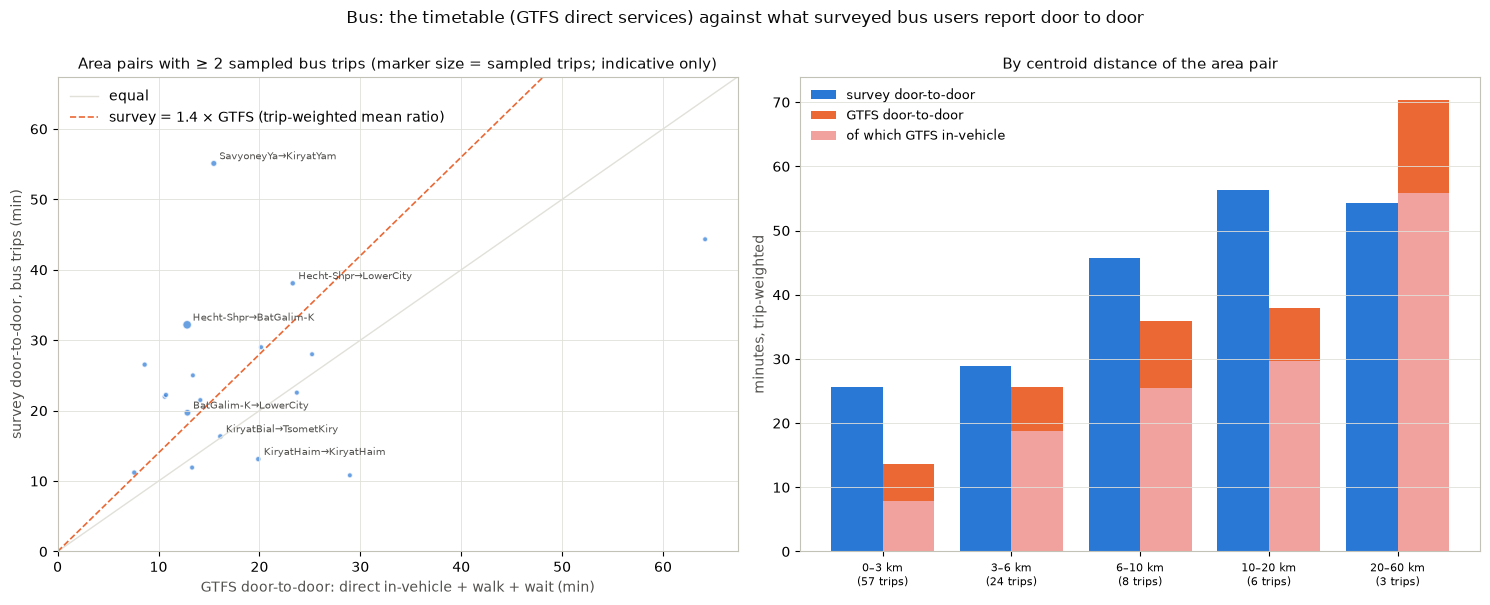

In [7]:
if HAVE_GTFS:
    lg = lb.copy()
    lg['gtfs_ivt'] = [bus_ivt_gtfs.loc[o, d_] for o, d_ in zip(lg['o'], lg['d'])]
    lg['gtfs_wait'] = [bus_wait_final.loc[o, d_] for o, d_ in zip(lg['o'], lg['d'])]
    lg['gtfs_walk'] = [bus_walk_final.loc[o, d_] for o, d_ in zip(lg['o'], lg['d'])]
    lg['gtfs_d2d'] = lg['gtfs_ivt'] + lg['gtfs_wait'] + lg['gtfs_walk']
    lg['dist_km'] = [DIST_KM.loc[o, d_] for o, d_ in zip(lg['o'], lg['d'])]
    lg['segment'] = np.where(lg['o'].between(201, 210) & lg['d'].between(201, 210), 'trunk–trunk', np.where(lg['o'].between(201, 212) | lg['d'].between(201, 212), 'trunk–branch', 'branch–branch'))
    direct_trips = lg.dropna(subset=['gtfs_ivt'])
    def wmean(x, col): return np.average(x[col], weights=x['w'])
    rows = []
    for lab, m in [('all pairs with a direct service', direct_trips['o'] == direct_trips['o'])] + [(seg_, direct_trips['segment'] == seg_) for seg_ in ['trunk–trunk', 'trunk–branch', 'branch–branch']] + [(f'{lo}–{hi} km', direct_trips['dist_km'].between(lo, hi)) for lo, hi in [(0, 3), (3, 6), (6, 10), (10, 20), (20, 60)]]:
        x = direct_trips[m]
        if x['share'].sum() < 3: continue
        rows.append({'subset': lab, 'sampled trips': x['share'].sum(), 'survey door-to-door (min)': wmean(x, 't'), 'GTFS in-vehicle (min)': wmean(x, 'gtfs_ivt'), 'GTFS walk (min)': wmean(x, 'gtfs_walk'), 'GTFS wait (min)': wmean(x, 'gtfs_wait'), 'GTFS door-to-door (min)': wmean(x, 'gtfs_d2d')})
    cmpg = pd.DataFrame(rows); cmpg['survey ÷ GTFS door-to-door'] = cmpg['survey door-to-door (min)'] / cmpg['GTFS door-to-door (min)']; cmpg['survey ÷ GTFS in-vehicle'] = cmpg['survey door-to-door (min)'] / cmpg['GTFS in-vehicle (min)']
    cmpg.to_csv(f'{OUT}/bus_gtfs_vs_survey_summary.csv', index=False, float_format='%.2f')
    no_direct = lg[lg['gtfs_ivt'].isna()]
    print(f"surveyed bus trips allocated to V2 pairs: {lg['share'].sum():.0f}; on pairs with a direct GTFS service {direct_trips['share'].sum():.0f} ({direct_trips['share'].sum() / lg['share'].sum():.0%}), on pairs without {no_direct['share'].sum():.0f} (survey door-to-door there {wmean(no_direct, 't'):.1f} min)")
    # pair level: pairs with >= 3 sampled trips
    pl = direct_trips.groupby(['o', 'd']).apply(lambda x: pd.Series({'n': x['share'].sum(), 'survey': wmean(x, 't'), 'gtfs_d2d': wmean(x, 'gtfs_d2d'), 'gtfs_ivt': wmean(x, 'gtfs_ivt'), 'dist_km': x['dist_km'].iloc[0]}), include_groups=False).reset_index()
    pl = pl[pl['n'] >= 2]; pl['o_name'] = pl['o'].map(names); pl['d_name'] = pl['d'].map(names); pl['ratio'] = pl['survey'] / pl['gtfs_d2d']
    pl.to_csv(f'{OUT}/bus_gtfs_vs_survey_pairs.csv', index=False, float_format='%.2f')
    print(f"pair level ({len(pl)} pairs with ≥ 2 sampled trips — too few for a fit): survey ÷ GTFS door-to-door median {pl['ratio'].median():.2f}, range {pl['ratio'].min():.2f}–{pl['ratio'].max():.2f}; the trip-level table below is the comparison to use")
    print(cmpg.round(1).to_string(index=False))
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor='white')
    ax = axes[0]; ax.scatter(pl['gtfs_d2d'], pl['survey'], s=8 + 3 * pl['n'], color=BLUE, alpha=0.7, edgecolors='white')
    lim = max(pl['survey'].max(), pl['gtfs_d2d'].max()) * 1.05; ax.plot([0, lim], [0, lim], color=GRID, lw=1, label='equal'); ax.plot([0, lim], [0, lim * 1.4], color=ORANGE, lw=1.2, ls='--', label='survey = 1.4 × GTFS (trip-weighted mean ratio)')
    for _, r in pl.nlargest(6, 'n').iterrows(): ax.annotate(f"{r['o_name'][:10]}→{r['d_name'][:10]}", (r['gtfs_d2d'], r['survey']), fontsize=7, color=INK2, xytext=(4, 3), textcoords='offset points')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_xlabel('GTFS door-to-door: direct in-vehicle + walk + wait (min)', color=INK2); ax.set_ylabel('survey door-to-door, bus trips (min)', color=INK2)
    ax.set_title('Area pairs with ≥ 2 sampled bus trips (marker size = sampled trips; indicative only)', color=INK, fontsize=11); ax.legend(frameon=False); ax.grid(True, color=GRID, lw=0.6); [s_.set_color(AXIS) for s_ in ax.spines.values()]
    ax = axes[1]; bands = cmpg[cmpg['subset'].str.contains('km')]; xb = np.arange(len(bands))
    ax.bar(xb - 0.2, bands['survey door-to-door (min)'], 0.4, color=BLUE, label='survey door-to-door'); ax.bar(xb + 0.2, bands['GTFS door-to-door (min)'], 0.4, color=ORANGE, label='GTFS door-to-door')
    ax.bar(xb + 0.2, bands['GTFS in-vehicle (min)'], 0.4, color='#f2a29e', label='of which GTFS in-vehicle')
    ax.set_xticks(xb); ax.set_xticklabels(bands['subset'] + '\n(' + bands['sampled trips'].round(0).astype(int).astype(str) + ' trips)', fontsize=8); ax.set_ylabel('minutes, trip-weighted', color=INK2)
    ax.set_title('By centroid distance of the area pair', color=INK, fontsize=11); ax.legend(frameon=False, fontsize=9); ax.grid(True, color=GRID, lw=0.6, axis='y'); [s_.set_color(AXIS) for s_ in ax.spines.values()]
    fig.suptitle('Bus: the timetable (GTFS direct services) against what surveyed bus users report door to door', color=INK, fontsize=12, y=1.0)
    plt.tight_layout(); fig.savefig('Output/figures/gc_bus_gtfs_vs_survey.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()
else:
    print('GTFS skim not available — comparison skipped')

## 3. LRT — in-vehicle time (step 25) and walk access / egress from the TAZs

In [8]:
st = pd.read_csv('Output/lrt_v2/lrt_stations_hf_lrt_3.csv'); stxy = st[['x', 'y']].values
lrt_ivt = {sc: pd.read_csv(f'Output/lrt_v2/lrt_area_ivt_{sc}.csv', index_col=0) for sc in ['all_underground', 'all_ground']}
lrt_ivt_section = {sc: pd.read_csv(f'Output/lrt_v2/lrt_station_times_{sc}_section_form.csv', index_col=0) for sc in ['all_underground', 'all_ground']}
for sc in lrt_ivt: lrt_ivt[sc].index = lrt_ivt[sc].index.astype(int); lrt_ivt[sc].columns = lrt_ivt[sc].columns.astype(int)
served_areas = list(lrt_ivt['all_underground'].index)
rep = ac['nearest_station']
lrt_ivt_sec_area = {sc: pd.DataFrame([[lrt_ivt_section[sc].loc[rep[o], rep[d_]] for d_ in served_areas] for o in served_areas], index=served_areas, columns=served_areas) for sc in lrt_ivt}
# walk access from every V2 TAZ to its nearest station (straight line × detour factor), then population- (origin) and employment- (destination) weighted per area
tk = key.copy(); tk['cx'] = [cent[t].x for t in tk['TAZ']]; tk['cy'] = [cent[t].y for t in tk['TAZ']]
tk['nearest_station'] = [st['station_id'][int(np.argmin(np.hypot(stxy[:, 0] - x, stxy[:, 1] - y)))] for x, y in zip(tk['cx'], tk['cy'])]
tk['dist_m'] = [np.min(np.hypot(stxy[:, 0] - x, stxy[:, 1] - y)) * DETOUR for x, y in zip(tk['cx'], tk['cy'])]
tk['walk_min'] = tk['dist_m'] / WALK_SPEED; tk['pop'] = pop.reindex(tk['TAZ']).values; tk['emp'] = emp.reindex(tk['TAZ']).values
tk['walkable'] = tk['dist_m'] <= 1200
tk.to_csv(f'{OUT}/lrt_access_taz_v2.csv', index=False, float_format='%.1f')
def wavg(g, col, w): return np.average(g[col], weights=g[w]) if g[w].sum() > 0 else g[col].mean()
acc = tk.groupby('AggCode').apply(lambda g: pd.Series({'access_walk_min_pop': wavg(g, 'walk_min', 'pop'), 'egress_walk_min_emp': wavg(g, 'walk_min', 'emp'), 'share_pop_walkable': (g['pop'] * g['walkable']).sum() / max(g['pop'].sum(), 1), 'share_emp_walkable': (g['emp'] * g['walkable']).sum() / max(g['emp'].sum(), 1)}), include_groups=False).reindex(AREAS)
acc['AggAreaName'] = names; acc['served_by_hf_lrt_3'] = acc.index.isin(served_areas)
acc.to_csv(f'{OUT}/lrt_access_area_v2.csv', float_format='%.3f')
print(f"served trunk areas: population-weighted access walk {acc.loc[served_areas, 'access_walk_min_pop'].min():.1f}–{acc.loc[served_areas, 'access_walk_min_pop'].max():.1f} min, share of residents within 1.2 km walking of a station {acc.loc[served_areas, 'share_pop_walkable'].min():.0%}–{acc.loc[served_areas, 'share_pop_walkable'].max():.0%}")
acc.round(2)

served trunk areas: population-weighted access walk 3.0–12.0 min, share of residents within 1.2 km walking of a station 78%–100%


,access_walk_min_pop,egress_walk_min_emp,share_pop_walkable,share_emp_walkable,AggAreaName,served_by_hf_lrt_3
AggCode,,,,,,
201,12.03,10.92,0.78,0.82,TiratCarmel,True
202,7.49,5.85,1.00,1.00,Matam-NeotPeres,True
203,5.49,6.19,1.00,1.00,HofCarmel-NeveDavid,True
204,6.10,6.31,1.00,1.00,Hecht-Shprintzak,True
205,7.10,7.10,1.00,1.00,EinHayam,True
206,4.85,6.97,1.00,1.00,BatGalim-KiryatEliezer,True
207,3.01,3.16,1.00,1.00,Hamoshava,True
208,3.83,5.21,1.00,1.00,LowerCity,True
209,4.77,8.60,1.00,0.98,Namal-Giborim,True


## 4. The component matrices, their status, and a first generalized-cost fill

In [9]:
MODES = ['car', 'bus', 'lrt_all_underground', 'lrt_all_ground'] + (['brt'] if HAVE_GTFS else [])
long = []
def add(mode, comp, M, status, source, unit='min'):
    for o in AREAS:
        for d_ in AREAS:
            v = M.loc[o, d_] if isinstance(M, pd.DataFrame) and o in M.index and d_ in M.columns else (M if np.isscalar(M) else np.nan)
            s = status.loc[o, d_] if isinstance(status, pd.DataFrame) else status
            long.append({'o': o, 'd': d_, 'mode': mode, 'component': comp, 'value': v, 'unit': unit, 'status': s if pd.notna(v) else 'missing', 'source': source})
# car
add('car', 'ivt', car_ivt, car_status, 'THS 2017/18 AM car trips, door-to-door TrvlTime; EB blend with t = a + b·km where < 10 sampled')
add('car', 'walk', 0.0, 'assumed', 'included in the door-to-door survey time'); add('car', 'wait', 0.0, 'assumed', 'n/a'); add('car', 'transfers', 0.0, 'assumed', 'n/a', 'count')
add('car', 'fare', 0.0, 'missing', 'operating cost per km × distance — needs נוהל פר"ת unit cost', 'ILS')
add('car', 'parking', PARKING, 'missing', 'parking charge by destination area — needs a tariff table; survey parkType gives the paid share', 'ILS')
# bus
bs = np.full((A, A), 'derived', dtype=object); np.fill_diagonal(bs, 'missing'); bus_status = pd.DataFrame(bs, index=AREAS, columns=AREAS)
add('bus', 'ivt_fastest_path_floor', bus_ivt, bus_status, 'fastest bus-served path, May 2026 link speeds weekday 3 07:00–08:00 (lower bound: no wait, no transfer, assumes a service on the path)')
if HAVE_GTFS:
    add('bus', 'ivt', bus_ivt_final, bus_ivt_status, ('step 30: observed IVT of the direct services routed over the May 2026 bus link speeds (derived); ' if HAVE_OBS else 'GTFS step 29: median scheduled IVT of the direct services (derived); ') + 'fastest-path floor × median GTFS/floor ratio where no direct service (assumed)')
    if HAVE_OBS: add('bus', 'ivt_scheduled', bus_ivt_sched, bus_ivt_status, 'GTFS step 29: median scheduled IVT of the direct services')
    add('bus', 'walk', bus_walk_final, 'derived', 'TAZ centroid → nearest served GTFS stop × 1.3 detour at 4.8 km/h; population-weighted access + employment-weighted egress')
    add('bus', 'wait', bus_wait_final, bus_wait_status, 'GTFS step 29: half the combined 07:00–08:00 headway of the direct services, capped at 10 min (derived); placeholder where no direct service (assumed)')
    add('bus', 'transfers', bus_tr_final, bus_tr_status, '0 where a direct service exists (GTFS); path building needed elsewhere', 'count')
    # the BRT as its own mode on the pairs it connects directly
    brt_st = pd.DataFrame(np.where(brt_ivt_gtfs.notna(), 'derived', 'missing'), index=AREAS, columns=AREAS)
    add('brt', 'ivt', brt_ivt_gtfs, brt_st, 'step 30: observed IVT of the direct Metronit services over the measured link speeds' if HAVE_OBS else 'GTFS step 29: median scheduled IVT of the direct Metronit services')
    add('brt', 'walk', bus_walk_final.where(brt_ivt_gtfs.notna()), brt_st, 'as bus (nearest served stop) — a BRT-stop-specific access is a refinement')
    add('brt', 'wait', (brt_hw_gtfs / 2).clip(upper=WAIT_CAP), brt_st, 'half the combined Metronit headway 07:00–08:00, capped at 10 min')
    add('brt', 'transfers', pd.DataFrame(0.0, index=AREAS, columns=AREAS).where(brt_ivt_gtfs.notna()), brt_st, 'direct service', 'count')
    add('brt', 'fare', FARE['bus'], 'missing', 'fare tables', 'ILS')
else:
    add('bus', 'ivt', bus_ivt, bus_status, 'fastest bus-served path (lower bound) — GTFS skim not yet available')
    add('bus', 'walk', BUS_WALK_DEFAULT, 'assumed', f'{BUS_WALK_DEFAULT:.0f} min access + egress placeholder — replace with GTFS stop locations')
    add('bus', 'wait', min(HEADWAY['bus'] / 2, WAIT_CAP), 'assumed', f'headway {HEADWAY["bus"]:.0f} min placeholder / 2 — replace with GTFS headways per pair')
    add('bus', 'transfers', np.nan, 'missing', 'route structure per pair — needs GTFS path building', 'count')
add('bus', 'fare', FARE['bus'], 'missing', 'fare tables (metropolitan fare zones)', 'ILS')
# lrt
for sc in ['all_underground', 'all_ground']:
    m = f'lrt_{sc}'; M = lrt_ivt[sc].reindex(index=AREAS, columns=AREAS)
    stt = pd.DataFrame(np.where(M.notna(), 'derived', 'missing'), index=AREAS, columns=AREAS)
    add(m, 'ivt', M, stt, f'step 25 station-to-station time, {sc}, decomposed form of the calibrated function (Red Line running time + stop penalty, levelled to the calibration); missing off hf_lrt_3 (211, 212, branches)')
    add(m, 'ivt_section_form', lrt_ivt_sec_area[sc].reindex(index=AREAS, columns=AREAS), stt, 'fast bound: one calibrated section per inter-station link')
    walk = pd.DataFrame(acc['access_walk_min_pop'].values[:, None] + acc['egress_walk_min_emp'].values[None, :], index=AREAS, columns=AREAS)
    add(m, 'walk', walk.where(stt == 'derived'), stt, 'TAZ centroid → nearest station × 1.3 detour at 4.8 km/h; population-weighted access + employment-weighted egress')
    add(m, 'wait', pd.DataFrame(min(HEADWAY['lrt'] / 2, WAIT_CAP), index=AREAS, columns=AREAS).where(stt == 'derived'), stt.replace('derived', 'assumed'), f'headway {HEADWAY["lrt"]:.0f} min (12 departures an hour, assumption of 22 Sep 2026) / 2')
    add(m, 'transfers', pd.DataFrame(0.0, index=AREAS, columns=AREAS).where(stt == 'derived'), stt.replace('derived', 'assumed'), 'single line on the trunk; branch transfers undefined until the branch alignments exist', 'count')
    add(m, 'fare', FARE['lrt'], 'missing', 'fare policy for the LRT (integrated with bus?)', 'ILS')
long = pd.DataFrame(long); long['value'] = long['value'].astype(float)
long.to_csv(f'{OUT}/gc_components_area_v2_long.csv', index=False, float_format='%.3f')
# generalized cost per mode with the plan's weights; missing money components enter at zero and are flagged
def gc_of(mode):
    c = long[long['mode'] == mode].pivot_table(index=['o', 'd'], columns='component', values='value', aggfunc='first').reindex(pd.MultiIndex.from_product([AREAS, AREAS], names=['o', 'd']))
    col = lambda k: c[k].fillna(0) if k in c else pd.Series(0.0, index=c.index)
    ivt = c['ivt']; walk = col('walk'); wait = col('wait'); tr = col('transfers'); money = col('fare') + col('parking')
    gc = ivt + W_WALK * walk + W_WAIT * wait + TRANSFER_PEN * tr + money / VOT * 60
    return gc.unstack('d').reindex(index=AREAS, columns=AREAS)
GC = {m: gc_of(m) for m in MODES}
for m in MODES: GC[m].to_csv(f'{OUT}/gc_area_v2_{m}.csv', float_format='%.2f')
status_summary = long.groupby(['mode', 'component', 'status']).size().unstack('status').fillna(0).astype(int)
cell_status = long[~long['component'].isin(['ivt_section_form', 'ivt_fastest_path_floor', 'ivt_scheduled'])].groupby(['mode', 'o', 'd'])['status'].apply(lambda s: '/'.join(f'{k}:{v}' for k, v in s.value_counts().sort_index().items())).unstack('d')
cell_status.to_csv(f'{OUT}/gc_cell_status_area_v2.csv')
print(status_summary.to_string())

status                                      assumed  derived  measured  missing
mode                component                                                  
brt                 fare                          0        0         0      625
                    ivt                           0      278         0      347
                    transfers                     0      278         0      347
                    wait                          0      278         0      347
                    walk                          0      278         0      347
bus                 fare                          0        0         0      625
                    ivt                         178      422         0       25
                    ivt_fastest_path_floor        0      600         0       25
                    ivt_scheduled                 0      422         0      203
                    transfers                     0      422         0      203
                    wait                

In [10]:
# ---- the gap table: what each component needs, mode by mode ----
inv = pd.DataFrame([
    ['car', 'ivt', 'derived', 'survey door-to-door times, 2017/18, smoothed', 'a 2026 congestion uplift (Google Distance Matrix sample on ~40 pairs at 07:30) or the national model car skim; intra-area times for the 174-TAZ market'],
    ['car', 'fare (operating cost)', 'missing', '—', 'per-km operating cost and the distance skim (survey TrvlDist is available per pair: car_dist_survey_area_v2.csv)'],
    ['car', 'parking', 'missing', 'survey parkType (paid / free) by destination area as a proxy', 'parking tariffs by destination area (Haifa municipality; Matam, Lower City, Bat Galim)'],
    ['car', 'VOT', 'missing', '—', 'נוהל פר"ת value of time by purpose (work / other), ILS per hour'],
    ['bus', 'ivt', 'derived (direct services)' if HAVE_GTFS else 'derived (lower bound)', 'GTFS scheduled IVT of direct services; fastest-path floor scaled elsewhere' if HAVE_GTFS else 'fastest bus-served path on the May 2026 speed network', 'transfer paths for the pairs without a direct service; observed (AVL) running times instead of the timetable'],
    ['bus', 'walk', 'derived' if HAVE_GTFS else 'assumed', 'TAZ centroid → nearest served GTFS stop' if HAVE_GTFS else f'{BUS_WALK_DEFAULT:.0f} min', 'a walking network instead of the 1.3 detour factor; stop-specific access for the routes actually used'],
    ['bus', 'wait', 'derived (direct services)' if HAVE_GTFS else 'assumed', 'half the GTFS combined headway of the direct services' if HAVE_GTFS else f'headway {HEADWAY["bus"]:.0f} min / 2', 'headway of the best route rather than the combined headway where lines diverge'],
    ['bus', 'transfers', 'derived where direct, missing elsewhere' if HAVE_GTFS else 'missing', '0 on direct pairs' if HAVE_GTFS else '—', 'GTFS path building (or the OnBoard survey transfer field tfrs, 9 % of trips carry it)'],
    ['brt', 'ivt / wait / walk', 'derived (direct Metronit pairs)' if HAVE_GTFS else 'missing', 'GTFS Metronit lines 83001, 67002, 67003, 62004, 52005' if HAVE_GTFS else '—', 'BRT-stop-specific walk access; a bus + BRT nest in the capture model'],
    ['bus', 'fare', 'missing', '—', 'fare tables of the metropolitan zones; integration with LRT'],
    ['lrt', 'ivt', 'derived (10 trunk areas)', 'calibrated function on hf_lrt_3 stations', 'alignment + stations of the segment Hamifrats → Tsomet Kiryat Ata and of the three branches (T1 Kiryat Ata – Nazareth, T2 Krayot, T3 Kiryat Yam); the regime (underground / ground) per section instead of the two pure scenarios; a running / dwell decomposition of the coefficients'],
    ['lrt', 'walk', 'derived (10 trunk areas)', 'TAZ centroid → nearest station', 'the same for the branch stations; a walking network instead of the 1.3 detour factor'],
    ['lrt', 'wait', 'assumed', f'headway {HEADWAY["lrt"]:.0f} min (12 departures an hour) / 2', 'the planned AM-peak headway per branch, confirmed by the operating plan'],
    ['lrt', 'transfers', 'assumed (0 on the trunk)', '—', 'the operating pattern: which branches are through-run, where the branches transfer'],
    ['lrt', 'fare', 'missing', '—', 'fare policy (integrated ticket with bus assumed)'],
    ['all', 'weights (walk 2.0, wait 2.0, transfer 8)', 'assumed (plan defaults)', 'LRT_CAPTURE_PLAN.md', 'confirm against נוהל פר"ת; calibrate λ on the 2022 shares once the skims are complete'],
    ['all', 'geography', 'partial', '25 V2 areas', 'TAZ 1509 (station S13) missing from the V2 aggregation; intra-area cells need a within-area treatment (task A2)'],
], columns=['mode', 'component', 'status', 'what exists now', 'what is needed to complete it'])
inv.to_csv(f'{OUT}/gc_data_inventory.csv', index=False); inv

,mode,component,status,what exists now,what is needed to complete it
0,car,ivt,derived,"survey door-to-door times, 2017/18, smoothed",a 2026 congestion uplift (Google Distance Matr...
1,car,fare (operating cost),missing,—,per-km operating cost and the distance skim (s...
2,car,parking,missing,survey parkType (paid / free) by destination a...,parking tariffs by destination area (Haifa mun...
3,car,VOT,missing,—,"נוהל פר""ת value of time by purpose (work / oth..."
4,bus,ivt,derived (direct services),GTFS scheduled IVT of direct services; fastest...,transfer paths for the pairs without a direct ...
5,bus,walk,derived,TAZ centroid → nearest served GTFS stop,a walking network instead of the 1.3 detour fa...
6,bus,wait,derived (direct services),half the GTFS combined headway of the direct s...,headway of the best route rather than the comb...
7,bus,transfers,"derived where direct, missing elsewhere",0 on direct pairs,GTFS path building (or the OnBoard survey tran...
8,brt,ivt / wait / walk,derived (direct Metronit pairs),"GTFS Metronit lines 83001, 67002, 67003, 62004...",BRT-stop-specific walk access; a bus + BRT nes...
9,bus,fare,missing,—,fare tables of the metropolitan zones; integra...


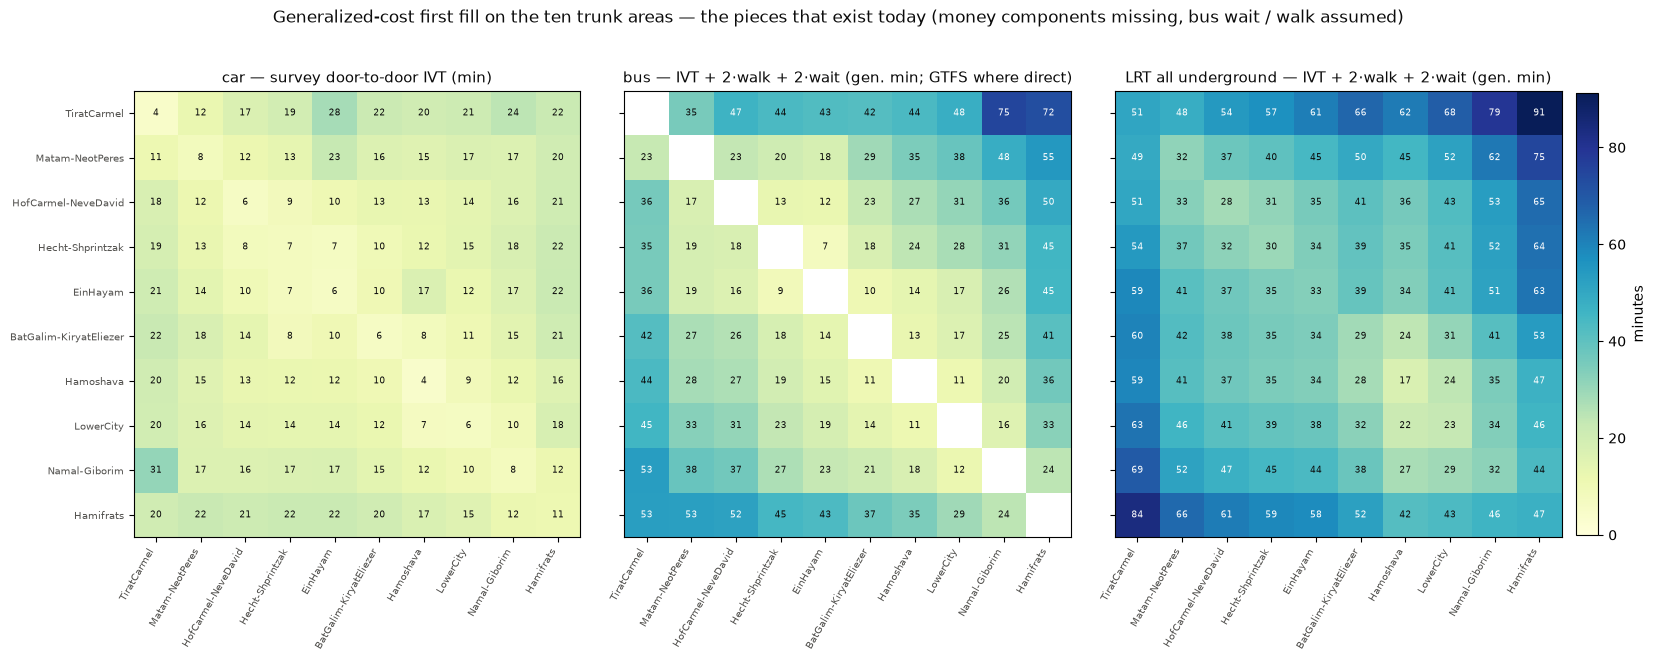

trunk pairs (90), trip-weighted means: car GC 14.5, bus partial GC 27.0, LRT underground partial GC 43.9, LRT ground 51.1 generalized minutes; LRT underground beats the bus partial GC on 0% of pairs and car on 0%


,pair,car GC,bus GC (partial),LRT underground GC (partial),LRT ground GC (partial),transit 2022 trips,car 2022 trips,LRT ug − bus,LRT ug − car
28,Hecht-Shprintzak → Matam-NeotPeres,12.8,18.5,36.5,41.2,348.3,146.1,18.0,23.7
46,BatGalim-KiryatEliezer → Matam-NeotPeres,17.7,27.4,42.2,51.9,303.3,356.5,14.8,24.5
31,Hecht-Shprintzak → BatGalim-KiryatEliezer,9.9,17.8,39.3,44.3,239.5,372.7,21.5,29.4
0,TiratCarmel → Matam-NeotPeres,12.3,35.3,48.3,53.0,219.5,1924.9,13.0,36.1
4,TiratCarmel → BatGalim-KiryatEliezer,21.7,41.7,66.4,80.8,147.8,452.5,24.6,44.6
88,Hamifrats → LowerCity,15.3,28.9,43.1,48.9,130.5,5.4,14.3,27.8
37,EinHayam → Matam-NeotPeres,14.3,18.6,41.2,47.6,116.3,61.0,22.6,26.9
33,Hecht-Shprintzak → LowerCity,14.5,27.6,41.4,49.9,115.6,32.4,13.8,26.8
73,Namal-Giborim → Matam-NeotPeres,16.6,38.4,51.5,67.2,108.2,11.4,13.2,35.0
79,Namal-Giborim → LowerCity,10.2,11.9,28.9,31.3,104.5,94.9,17.0,18.7


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.8), facecolor='white', gridspec_kw={'wspace': 0.08})
trunk = [a for a in AREAS if 201 <= a <= 210]
for ax, (m, title) in zip(axes, [('car', 'car — survey door-to-door IVT (min)'), ('bus', 'bus — IVT + 2·walk + 2·wait (gen. min; GTFS where direct)' if HAVE_GTFS else 'bus — fastest bus-served path IVT, 07:00–08:00 (min)'), ('lrt_all_underground', 'LRT all underground — IVT + 2·walk + 2·wait (gen. min)')]):
    M = GC[m].reindex(index=trunk, columns=trunk).values.astype(float)
    im = ax.imshow(M, cmap='YlGnBu', vmin=0, vmax=np.nanmax([np.nanmax(GC[k].reindex(index=trunk, columns=trunk).values) for k in ['car', 'bus', 'lrt_all_underground']]))
    ax.set_xticks(range(len(trunk))); ax.set_xticklabels([names[a] for a in trunk], rotation=60, ha='right', fontsize=7.5, color=INK2); ax.set_yticks(range(len(trunk))); ax.set_yticklabels([names[a] for a in trunk] if ax is axes[0] else [], fontsize=7.5, color=INK2)
    for i in range(len(trunk)):
        for j in range(len(trunk)):
            if np.isfinite(M[i, j]): ax.text(j, i, f'{M[i, j]:.0f}', ha='center', va='center', fontsize=6.5, color='white' if M[i, j] > 45 else INK)
    ax.set_title(title, color=INK, fontsize=10.5)
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01, label='minutes')
fig.suptitle('Generalized-cost first fill on the ten trunk areas — the pieces that exist today (money components missing, bus wait / walk assumed)', color=INK, fontsize=12, y=1.02)
fig.savefig('Output/figures/gc_first_fill_trunk_v2.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()
# side-by-side on the served pairs: how the three modes compare before calibration
pairs = [(o, d_) for o in trunk for d_ in trunk if o != d_]
cmpdf = pd.DataFrame({'pair': [f'{names[o]} → {names[d_]}' for o, d_ in pairs], 'car GC': [GC['car'].loc[o, d_] for o, d_ in pairs], 'bus GC (partial)': [GC['bus'].loc[o, d_] for o, d_ in pairs],
                      'LRT underground GC (partial)': [GC['lrt_all_underground'].loc[o, d_] for o, d_ in pairs], 'LRT ground GC (partial)': [GC['lrt_all_ground'].loc[o, d_] for o, d_ in pairs],
                      'transit 2022 trips': [pd.read_csv('Output/corridor_v2/transit_2022_area_v2.csv', index_col=0).loc[o, str(d_)] for o, d_ in pairs], 'car 2022 trips': [pd.read_csv('Output/corridor_v2/car_2022_area_v2.csv', index_col=0).loc[o, str(d_)] for o, d_ in pairs]})
cmpdf['LRT ug − bus'] = cmpdf['LRT underground GC (partial)'] - cmpdf['bus GC (partial)']; cmpdf['LRT ug − car'] = cmpdf['LRT underground GC (partial)'] - cmpdf['car GC']
cmpdf.to_csv(f'{OUT}/gc_trunk_pairs_comparison.csv', index=False, float_format='%.1f')
w = cmpdf['transit 2022 trips'] + cmpdf['car 2022 trips']
print(f"trunk pairs ({len(pairs)}), trip-weighted means: car GC {np.average(cmpdf['car GC'], weights=w):.1f}, bus partial GC {np.average(cmpdf['bus GC (partial)'], weights=w):.1f}, "
      f"LRT underground partial GC {np.average(cmpdf['LRT underground GC (partial)'], weights=w):.1f}, LRT ground {np.average(cmpdf['LRT ground GC (partial)'], weights=w):.1f} generalized minutes; "
      f"LRT underground beats the bus partial GC on {(cmpdf['LRT ug − bus'] < 0).mean():.0%} of pairs and car on {(cmpdf['LRT ug − car'] < 0).mean():.0%}")
cmpdf.sort_values('transit 2022 trips', ascending=False).head(15).round(1)

## Findings

- **Car (derived).** 2,387 sampled AM car trips of the survey have both ends in the 25 V2 areas and a door-to-door time; they cover 296 of the 625 area pairs, 35 of them with ten or more sampled trips. The distance fit on the off-diagonal cells is *t* = 7.0 + 1.85 × km (a 32 km/h marginal speed and a 7-minute terminal time); intra-area trips average 7.0 min. The trip-weighted car time on the 90 trunk pairs is 14.5 min. Vintage 2017 / 18, door-to-door — parking search included, no 2026 congestion uplift.
- **Bus (derived, lower bound).** The May 2026 speed network has 54,507 street links (5,632 km) in the study area, 48,092 of them with a Tuesday 07:00–08:00 bus speed (4,995 km). The fastest bus-served path between area centroids takes 3–69 min (path speed median 34 km/h — the motorway links carry bus speeds too). On the trunk pairs the trip-weighted network IVT is 12.5 min against **27.1 min door-to-door in the survey** (37 sampled bus trips; 32.4 vs 15.3 min on all V2 pairs, 102 trips): walk, wait, stops and route detours double the fastest-path time. The network value is the running-speed floor; the survey value is what a GTFS-based skim with walk and wait should reproduce.
- **The GTFS bus skim against the survey, pair by pair (2d).** On the pairs with a direct service (97 % of the surveyed bus trips) the timetable's door-to-door time — direct in-vehicle 15.8 + walk 5.3 + wait 1.9 = 23.0 min trip-weighted — is 1.4 × below what the same travellers report (31.8 min); in-vehicle time alone is 2.0 × below. The gap is a fixed overhead, not a proportional one: on pairs under 3 km apart the survey is 1.9 × the timetable (25.6 against 13.5 min — a 12-minute overhead on a 8-minute ride), on 3–20 km pairs 1.3 ×, and on the few 20–60 km pairs the two agree (54 against 63 min). Trunk-to-trunk pairs: 26.8 reported against 17.4 scheduled. Read as a calibration: survey door-to-door ≈ GTFS door-to-door + 9 minutes, or the wait set to the headway of the line actually needed rather than half the pooled headway plus the transfer that a third of bus journeys involve. Only three pairs hold three or more sampled trips, so this is a trip-level result by distance band, not a pair-level fit.
- **LRT (derived on the ten trunk areas, missing elsewhere; revised with step 25's corrected function).** Walk access is 3–12 min population-weighted (Tirat Carmel and Hamifrats at the far end; 78–100 % of residents within 1.2 km of a station); trip-weighted access + egress on the trunk pairs 13.6 min, against 4.7 min to the nearest bus stop. In-vehicle time on the trunk pairs, trip-weighted: **11.7 min all underground / 18.9 min all ground** in the decomposed form of step 25 (the section form gives 13.3 / 16.2), level with the bus timetable's 12.3 min. With the 5-minute headway (12 departures an hour, wait 2.5 min) the partial generalized cost (IVT + 2 × walk + 2 × wait) is 43.9 (underground) / 51.1 (ground) against 24.9 for the GTFS-based bus and 14.5 for car: the LRT is dearer than the bus on every trunk pair by 7–31 generalized minutes (median 17), and 18 of those are the access difference (2 × (13.6 − 4.7)). Door to door the underground LRT (11.7 + 13.6 + 2.5 ≈ 28 min) equals what bus users report today (27 min) and is 10 minutes slower than the bus timetable's best direct service (17 min); the ground-level LRT (≈ 35 min) is slower than both.
- **What decides the answer is not what is missing but what is uncertain.** The money components (fare, parking, VOT) are missing for every mode, bus walk / wait are placeholders and bus transfers are absent — but at a plausible VOT they move the comparison by a few generalized minutes. With the calibrated function now transferred to Haifa's spacing through the Red Line's running-time / stop-penalty decomposition (step 25, revision 2), the LRT's in-vehicle time is no longer the open question: it is level with the bus timetable underground and 7 minutes slower at ground level. What separates the LRT from the bus in this first fill is **station access** — 24 stations against 12,845 stops, 13.6 against 4.7 minutes of walking on the trunk pairs — and that is a matter of the access model (feeder buses, the walking network, park-and-ride) and of the station plan, not of the travel-time function. The two inputs to obtain first are therefore E1 (the branch alignments and stations, since 15 of the 25 areas have no LRT time at all) and an access / feeder treatment for the LRT; the money components follow.
- **Status of the fill** (`gc_components_area_v2_long.csv`): car IVT 35 measured / 590 derived cells; bus IVT 600 derived (diagonal missing); LRT IVT 100 derived / 525 missing per scenario; every fare / parking cell missing; bus walk and wait assumed on all 625 cells; bus transfers missing. The gap table `gc_data_inventory.csv` lists, component by component, what exists and what closes it.
- **Outputs.** `Output/gc/car_ivt_survey_area_v2.csv` (+ `_n_sampled`, `car_dist_survey_area_v2.csv`), `bus_ivt_network_area_v2.csv`, `bus_path_km_area_v2.csv`, `bus_survey_vs_network_check.csv`, `lrt_access_taz_v2.csv`, `lrt_access_area_v2.csv`, `gc_components_area_v2_long.csv`, `gc_area_v2_{car,bus,lrt_all_underground,lrt_all_ground}.csv`, `gc_cell_status_area_v2.csv`, `gc_trunk_pairs_comparison.csv`, `bus_gtfs_vs_survey_summary.csv`, `bus_gtfs_vs_survey_pairs.csv`, `gc_data_inventory.csv`; figures `gc_first_fill_trunk_v2.png`, `gc_bus_gtfs_vs_survey.png`.